# 📽️ **Reprojection**

> ### 📌 **TL;DR**
>
> This Jupyter notebook has been created to compare different features with several open source Python libraries for rasters management.
>
> This notebook compares raster reprojection capabilities across several libraries.
>
> The following libraries will be considered :
>- `rasterio`
>- `rioxarray`
>- `odc-geo`
>- `geoutils`
>- `xarray-spatial`

In [ ]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.plot import show

import rioxarray as rxr

from odc.geo.xr import xr_reproject

import geoutils as gu

import xrspatial as xrs
from xrspatial.geotiff import open_geotiff
from xrspatial.reproject import reproject as xrs_reproject

import matplotlib.pyplot as plt
import seaborn # cmap mako

In [2]:
# path to the raster object
raster_path = "../data/rasters/105005005BDEA700-visual.tif"

## **Reprojection (without RPCs)**

Reprojecting a raster is available in every library considered in this study.

It consists of converting a raster to a different coordinate reference system (*CRS*).

Reprojection can be done for many different reasons :
- to make sure the image is correctly aligned and standardized with other data
- to work in a specific projection suitable for the intended use (for instance, distance or area measurements)
- orthorectifying data with RPCs/ GCPs
- to adapt the resolution and pixels size
- to change the grid
- to translate or apply a rotation
- to publish or share data on some platforms/ web services that require a specific projection
- ...

### • *rasterio*

In [9]:
ds_rasterio = rasterio.open(raster_path)

In [10]:
for key, value in ds_rasterio.meta.items():
    print(f"{key} : {value}")

driver : GTiff
dtype : uint8
nodata : None
width : 8705
height : 8705
count : 3
crs : EPSG:32627
transform : | 0.64, 0.00, 429724.70|
| 0.00,-0.64, 7085270.84|
| 0.00, 0.00, 1.00|


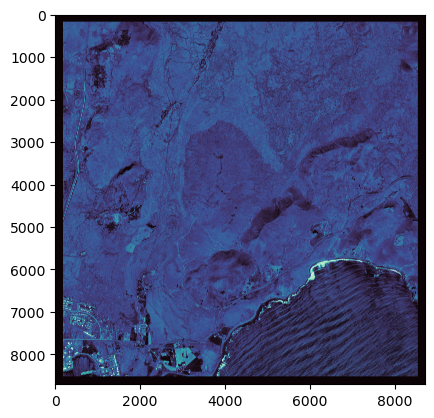

<Axes: >

In [11]:
show(ds_rasterio.read(1), cmap="mako")

In [12]:
print(f"Dataset's CRS : {ds_rasterio.crs}")

Dataset's CRS : EPSG:32627


Our raster is currently projected in `EPSG:32627`, and we want it to be converted to `EPSG:4326`.

`rasterio`'s workflow is convoluted:

- we will use the [`calculate_default_transform()`](https://rasterio.readthedocs.io/en/stable/api/rasterio.warp.html#rasterio.warp.calculate_default_transform) function to transform bounds to target coordinate system, calculate resolution, and returns destination transform and dimensions;
- we will then use [`reproject()`](https://rasterio.readthedocs.io/en/stable/api/rasterio.warp.html#rasterio.warp.reproject) to reproject our raster to the new CRS. The reprojection with `rasterio` is performed eagerly. Since it works on numpy arrays, the reading is done instantly, and reprojecting triggers calculations and load data into memory, which can be a problem on very large images.

In `rasterio`, unlike other libraries, the number of arguments that need to be specified as inputs for the reprojection makes it non-trivial.
Moreover, the metadata management is not an easy task : we first need to copy the metadata of our input raster, and pass them as an argument during the reprojection, so the output raster has its own metadata, which is not really convenient.

In [13]:
dst_crs = "EPSG:4326" # targeted CRS

dst_path = "../outputs/rasterio_reproj.tif"

with rasterio.open(raster_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    kwargs = src.meta.copy() # copy metadata
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    with rasterio.open(dst_path, 'w', **kwargs) as dst:
        for i in range(1, src.count + 1): # band-by-band reprojection
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest)

We can then plot our new image and its associated metadata:

driver : GTiff
dtype : uint8
nodata : None
width : 11340
height : 5002
count : 3
crs : EPSG:4326
transform : | 0.00, 0.00,-22.43|
| 0.00,-0.00, 63.89|
| 0.00, 0.00, 1.00|


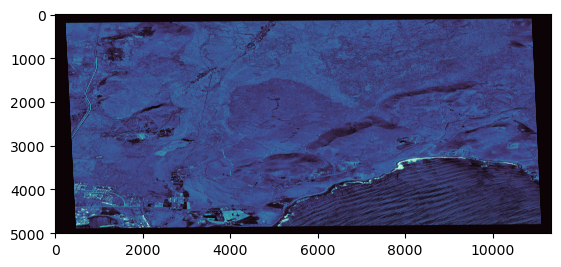

In [14]:
with rasterio.open(dst_path) as rasterio_reproj:
    for key, value in rasterio_reproj.meta.items():
        print(f"{key} : {value}")
    show(rasterio_reproj.read(1), cmap="mako")

### • *rioxarray*

With `rioxarray`, we will use the [`.reproject()`](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_array.RasterArray.reproject) function :

In [15]:
ds_rxr = rxr.open_rasterio(raster_path, chunks={'x': 2048, 'y': 2048})

Here are the metadata of our dataset:

In [16]:
print(f"""
Dimensions : {ds_rxr.dims}
Number of band(s) : {ds_rxr.rio.count}
Data type : {ds_rxr.dtype}
Shape : {ds_rxr.shape}
Size : {ds_rxr.rio.height} rows x {ds_rxr.rio.width} columns
CRS : {ds_rxr.rio.crs}
Resolution : {ds_rxr.rio.resolution()}
Bounds : {ds_rxr.rio.bounds()}
Transform : {ds_rxr.rio.transform()}
Attributes : {ds_rxr.attrs}
""")


Dimensions : ('band', 'y', 'x')
Number of band(s) : 3
Data type : uint8
Shape : (3, 8705, 8705)
Size : 8705 rows x 8705 columns
CRS : EPSG:32627
Resolution : (0.6366138318386534, -0.6366130005392807)
Bounds : (429724.7032134462, 7079729.124170403, 435266.42661960167, 7085270.840340097)
Transform : | 0.64, 0.00, 429724.70|
| 0.00,-0.64, 7085270.84|
| 0.00, 0.00, 1.00|
Attributes : {'DataType': 'Generic', 'AREA_OR_POINT': 'Area', 'RepresentationType': 'ATHEMATIC', 'STATISTICS_APPROXIMATE': 'YES', 'STATISTICS_COUNT': 75777025.0, 'STATISTICS_COVARIANCES': '1132.19211386189,964.682627130038,855.4449300280452', 'STATISTICS_MAXIMUM': 255, 'STATISTICS_MEAN': 72.39914918805, 'STATISTICS_MEDIAN': 78.0, 'STATISTICS_MINIMUM': 0, 'STATISTICS_SKIPFACTORX': 1, 'STATISTICS_SKIPFACTORY': 1, 'STATISTICS_STDDEV': 33.648062557328, 'STATISTICS_VALID_PERCENT': 100, 'scale_factor': 1.0, 'add_offset': 0.0}



`rioxarray` greatly simplifies the metadata management compared to `rasterio`.

The [`.reproject()`](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_array.RasterArray.reproject) function is more straightforward than in `rasterio`, we just need to specify the targeted CRS.

Since we have opened our raster with chunks, the data is lazy and stored as `dask` tasks. When calling the reproject function, it will create a `dask` graph but calculations are only executed when calling `.compute()`, or when saving the array to a new file.

In [17]:
dst_crs = "EPSG:4326" #targeted CRS

rxr_reproj = ds_rxr.rio.reproject(dst_crs)

We can now verify the new CRS and image:

In [18]:
print(f"""
Dimensions : {rxr_reproj.dims}
Number of band(s) : {rxr_reproj.rio.count}
Data type : {rxr_reproj.dtype}
Shape : {rxr_reproj.shape}
Size : {rxr_reproj.rio.height} rows x {rxr_reproj.rio.width} columns
CRS : {rxr_reproj.rio.crs}
Resolution : {rxr_reproj.rio.resolution()}
Bounds : {rxr_reproj.rio.bounds()}
Transform : {rxr_reproj.rio.transform()}
Attributes : {rxr_reproj.attrs}
""")


Dimensions : ('band', 'y', 'x')
Number of band(s) : 3
Data type : uint8
Shape : (3, 5002, 11340)
Size : 5002 rows x 11340 columns
CRS : EPSG:4326
Resolution : (1.0153558723919694e-05, -1.0153558723919694e-05)
Bounds : (-22.431107657144402, 63.837824842876195, -22.315966301215152, 63.88861294361324)
Transform : | 0.00, 0.00,-22.43|
| 0.00,-0.00, 63.89|
| 0.00, 0.00, 1.00|
Attributes : {'DataType': 'Generic', 'AREA_OR_POINT': 'Area', 'RepresentationType': 'ATHEMATIC', 'STATISTICS_APPROXIMATE': 'YES', 'STATISTICS_COUNT': 75777025.0, 'STATISTICS_COVARIANCES': '1132.19211386189,964.682627130038,855.4449300280452', 'STATISTICS_MAXIMUM': 255, 'STATISTICS_MEAN': 72.39914918805, 'STATISTICS_MEDIAN': 78.0, 'STATISTICS_MINIMUM': 0, 'STATISTICS_SKIPFACTORX': 1, 'STATISTICS_SKIPFACTORY': 1, 'STATISTICS_STDDEV': 33.648062557328, 'STATISTICS_VALID_PERCENT': 100, 'scale_factor': 1.0, 'add_offset': 0.0, '_FillValue': 255}



And we can plot the new image:

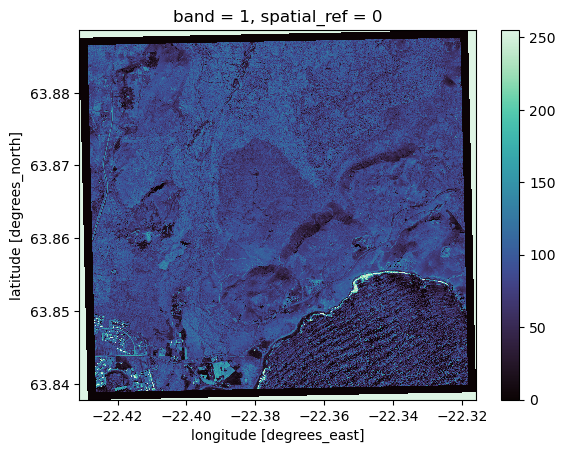

In [19]:
rxr_reproj[0].plot.imshow(cmap="mako")

### • *odc-geo*

With `odc-geo`, we will use the [`.xr_reproject()`](https://odc-geo.readthedocs.io/en/latest/_api/odc.geo.xr.xr_reproject.html) function to reproject our raster, which is more generic and flexible than [`.ODCExtensionDa.reproject()`](https://odc-geo.readthedocs.io/en/latest/_api/odc.geo.xr.ODCExtensionDa.reproject.html), that can also be used on `DataArrays` already odc-compatible. Both functions are doing almost the same, the only difference is that ODCExtensionDa.reproject() allows to do the reprojection directly on the object itself and will calculate automatically the targeted grid (`GeoBox`) with the given CRS.

In [21]:
ds_odcgeo = rxr.open_rasterio(raster_path, chunks={'x' : 2048, 'y' : 2048})

We can simply pass the image and the desired CRS as arguments.

`odc-geo` has implemented a lazy version of the reprojection, called `xr_reproject`. This function will create new dask tasks for reprojection but will not trigger instant calculations.

> dask tip: Keep the `ds_odcgeo` chunked to make full use of this lazy graph, especially if reprojecting large datasets.

In [22]:
dst_crs = "EPSG:4326"

odcgeo_reproj = xr_reproject(ds_odcgeo, dst_crs)

Our new raster has now the expected CRS:

In [23]:
print(odcgeo_reproj.rio.crs)

EPSG:4326


Let's plot the newly created raster (the computation should be triggered by the plot and this may take a bit of time):

c:\Users\cbernaert\AppData\Local\anaconda3\envs\rasters_lib_comp\Lib\site-packages\rasterio\warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


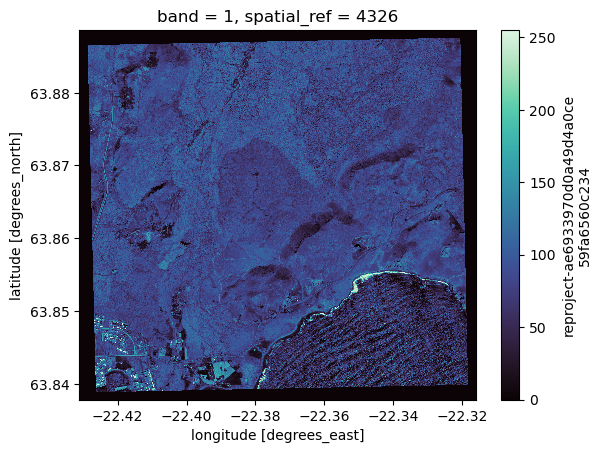

In [24]:
odcgeo_reproj[0].plot.imshow(cmap="mako")

### • *geoutils*

In `geoutils`, we will use the [`.reproject()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.reproject.html#geoutils.Raster.reproject) function:

In [25]:
ds_geoutils = gu.Raster(raster_path)

In [26]:
print(f"Dataset's CRS : {ds_geoutils.crs}")

Dataset's CRS : EPSG:32627


To reproject, we can simply pass the targeted CRS as an argument.

When using the `.reproject` function, data will be loaded instantly, will do the reprojection using memory and will return the newly created object with the reprojection result.

In [27]:
gu_reprojected = ds_geoutils.reproject(crs=dst_crs)

However, `geoutils` will release soon an `xarray` accessor and with it a lazy version of its reprojection, leveraging `dask` as seen in the documentation:
 > reprojection can be computed out-of-memory in multiprocessing, by passing a MultiprocConfig object. The reprojected raster is written to disk under the path specified in the configuration.

In [28]:
print(f"Reprojected Dataset's CRS : {gu_reprojected.crs}")

Reprojected Dataset's CRS : EPSG:4326


We can finally plot the new raster:

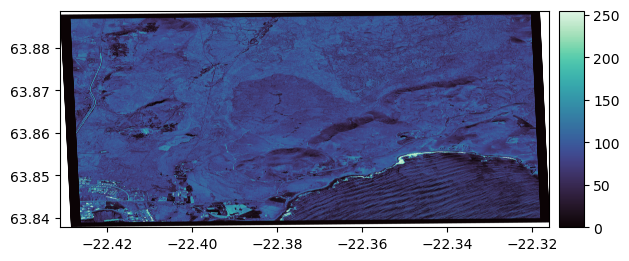

In [29]:
gu_reprojected.plot(bands=1, cmap="mako")

### • *xarray-spatial*

`xarray-spatial` supports Reprojecting using its built-in [`.reproject()`](https://xarray-spatial.readthedocs.io/en/stable/reference/_autosummary/xrspatial.reproject.reproject.html#xrspatial.reproject.reproject) function.

This feature can be used with `dask`-backed inputs, as mentioned in the documentation :
> For dask inputs, the computation is fully lazy: each output chunk independently reads only the source pixels it needs.

It also allows to specify the output chunk size for `dask`, with the `chunk_size` argument. If not using `dask`, the `max_memory` argument can be specified to set the maximum memory budget allowed for the reprojection.

As for previous examples, we will reproject our current dataset from `EPSG:32627` to `EPSG:4326`.

In [30]:
ds_xrs = open_geotiff(raster_path, chunks=2048, allow_internal_only_jpeg=True)

In [32]:
print(ds_xrs.crs)

32627


We will just specify our new CRS, by passing the `target_crs` argument to the `reproject` function :

In [34]:
ds_xrs_reprojected = xrs_reproject(ds_xrs, target_crs="EPSG:4326")

We can finally verify the CRS of our reprojected dataset :

In [35]:
print(ds_xrs_reprojected.crs)

GEOGCS["WGS 84",DATUM["WGS84",SPHEROID["WGS84",6378137.0,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433],AUTHORITY["EPSG","4326"]]


## **Reproject match**

Reproject match is a feature only available in `rioxarray` and `geoutils` libraries.

This feature is useful to reproject an image to match the exact projection, resolution and grid of another raster without extracting these information by hand and repassing them to the classic reprojection function, making it a very useful shortcut to simplify this task.

In this example we will reproject a DEM (Digital Elevation Model) on a satellite image with a different CRS.

### • *rioxarray*

With `rioxarray`, we can use the [`.reproject_match()`](https://corteva.github.io/rioxarray/stable/examples/reproject_match.html) function:

In this example we will reproject a DEM imagery of Sardinia with an different CRS to align it with another raster that has the correct one.

In [36]:
#path of the sat image
raster_path = "../data/rasters/T32TNK_20251113T101159_TCI.tif"

In [37]:
#path of the dem with the different CRS
dem_different_crs_path = "../data/rasters/sard1.tif"

In [38]:
da_rxr_valid = rxr.open_rasterio(raster_path, chunks={'x' : 2048, 'y' : 2048})

da_rxr_dem_invalid = rxr.open_rasterio(dem_different_crs_path, chunks={'x' : 2048, 'y' : 2048})

In [39]:
print(f"""
VALID RASTER ATTRIBUTES\n
shape: {da_rxr_valid.rio.shape}
resolution: {da_rxr_valid.rio.resolution()}
bounds: {da_rxr_valid.rio.bounds()}
CRS: {da_rxr_valid.rio.crs}
""")


VALID RASTER ATTRIBUTES

shape: (5490, 5490)
resolution: (20.0, -20.0)
bounds: (499980.0, 4390200.0, 609780.0, 4500000.0)
CRS: EPSG:32632



Here is the reference raster that we want to match:

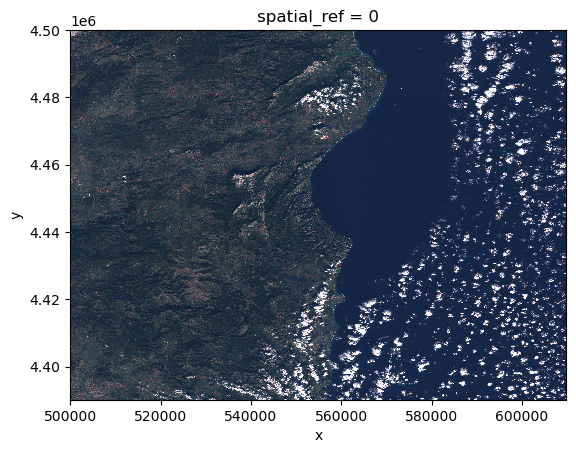

In [40]:
da_rxr_valid.plot.imshow()
plt.show()

In [41]:
print(f"""
DEM DIFFERENT CRS ATTRIBUTES\n
shape: {da_rxr_dem_invalid.rio.shape}
resolution: {da_rxr_dem_invalid.rio.resolution()}
bounds: {da_rxr_dem_invalid.rio.bounds()}
CRS: {da_rxr_dem_invalid.rio.crs} <-- to be changed
""")


DEM DIFFERENT CRS ATTRIBUTES

shape: (4918, 2881)
resolution: (50.0, -50.0)
bounds: (4162400.0, 1754100.0, 4306450.0, 2000000.0)
CRS: EPSG:3035 <-- to be changed



We can plot the DEM with different CRS, but first we will convert nodata values to NaNs:

In [42]:
da_rxr_dem_invalid = da_rxr_dem_invalid.where(da_rxr_dem_invalid != da_rxr_dem_invalid.rio.nodata)

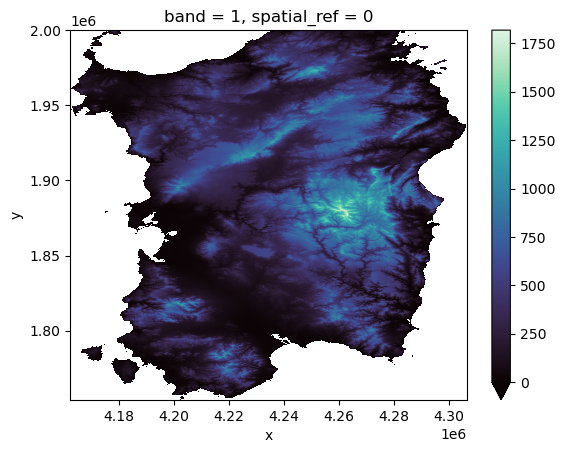

In [43]:
da_rxr_dem_invalid.sel(band=1).plot.imshow(cmap="mako", vmin=0)

DEM's CRS is `IGNF:ETRS89UTM32` and we want to align it onto the satellite image one: `EPSG:32632` (CRS of the reference raster).

We can use the [`reproject_match()`](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_array.RasterArray.reproject_match) function, for that we just have to pass the raster correctly projected as an argument:

In [44]:
rxr_repr_match = da_rxr_dem_invalid.rio.reproject_match(da_rxr_valid)

If we check the newly projected raster, its CRS has been changed accordingly to our referenced raster:

In [45]:
print(f"""
REPROJECTED RASTER ATTRIBUTES\n
shape: {rxr_repr_match.rio.shape}
resolution: {rxr_repr_match.rio.resolution()}
bounds: {rxr_repr_match.rio.bounds()}
CRS: {rxr_repr_match.rio.crs}
""")


REPROJECTED RASTER ATTRIBUTES

shape: (5490, 5490)
resolution: (20.0, -20.0)
bounds: (499980.0, 4390200.0, 609780.0, 4500000.0)
CRS: EPSG:32632



We can now plot our reference raster with the reprojected DEM on top, as follows:

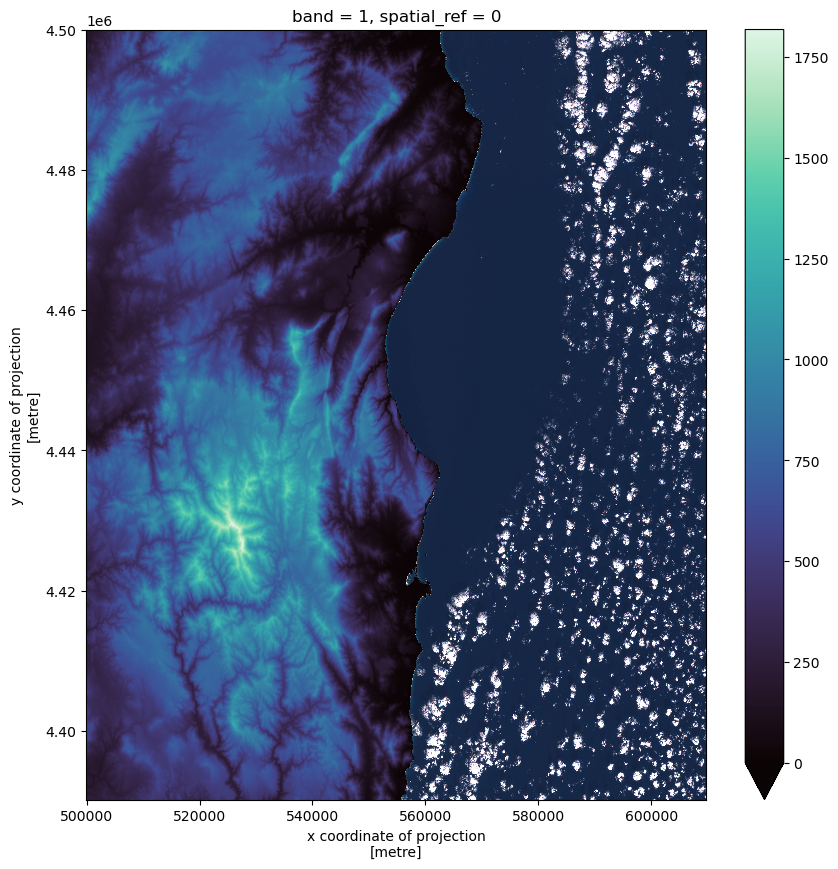

In [46]:
fig,ax = plt.subplots(figsize=(10, 10))

da_rxr_valid.plot.imshow(ax=ax)

rxr_repr_match.where(rxr_repr_match!=rxr_repr_match.rio.nodata).sel(band=1).plot.imshow(ax=ax, cmap="mako", add_colorbar=True, vmin=0)

plt.show()

### • *geoutils*

To reproject match using `geoutils`, we will reuse the [`.reproject()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.reproject.html) function already seen previously, but this time we will pass the argument `ref=` with another raster, so our image will be reprojected according to the resolution, bounds and CRS of this referenced raster.


In [47]:
gu_rast_valid = gu.Raster(raster_path)

gu_rast_invalid = gu.Raster(dem_different_crs_path)

In [48]:
gu_rast_valid.info()

Driver:               GTiff 
Opened from file:     ../data/rasters/T32TNK_20251113T101159_TCI.tif 
Filename:             ../data/rasters/T32TNK_20251113T101159_TCI.tif 
Loaded?               False 
Modified since load?  False 
Grid size:            5490, 5490
Number of bands:      3
Data types:           uint8
Coordinate system:    ['EPSG:32632']
Nodata value:         None
Pixel interpretation: Area
Pixel size:           20.0, 20.0
Upper left corner:    499980.0, 4500000.0
Lower right corner:   609780.0, 4390200.0



In [49]:
gu_rast_invalid.info()

Driver:               GTiff 
Opened from file:     ../data/rasters/sard1.tif 
Filename:             ../data/rasters/sard1.tif 
Loaded?               False 
Modified since load?  False 
Grid size:            2881, 4918
Number of bands:      1
Data types:           float32
Coordinate system:    ['EPSG:3035']
Nodata value:         -3.4028234663852886e+38
Pixel interpretation: Area
Pixel size:           50.0, 50.0
Upper left corner:    4162400.0, 2000000.0
Lower right corner:   4306450.0, 1754100.0



As previously, we can reuse the `reproject()` function, but this time we pass our valid raster as an argument:

In [50]:
gu_reproj = gu_rast_invalid.reproject(ref=gu_rast_valid)

The reprojected raster has now the expected CRS :

In [51]:
gu_reproj.info()

Driver:               None 
Opened from file:     None 
Filename:             None 
Loaded?               True 
Modified since load?  True 
Grid size:            5490, 5490
Number of bands:      1
Data types:           float32
Coordinate system:    ['EPSG:32632']
Nodata value:         -3.4028234663852886e+38
Pixel interpretation: Area
Pixel size:           20.0, 20.0
Upper left corner:    499980.0, 4500000.0
Lower right corner:   609780.0, 4390200.0



Finally, we can plot our reprojected DEM on top of our reference raster, as follows:

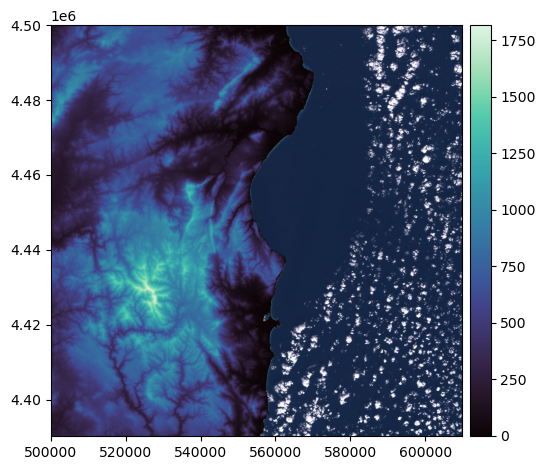

In [52]:
gu_rast_valid.plot()
gu_reproj.plot(cmap="mako")